# Reproducing Krapp et al. (2024) Figures 2, 4, and 5 with the AthenaK dust module

This notebook reproduces the drag-solver validation figures of **Krapp, Garrido-Deutelmoser,
Benítez-Llambay & Kratter (2024), ApJS 271, 7** using our Lagrangian particle implementation
(`src/dust/`), instead of their Eulerian multifluid code:

- **Figure 2** — gas + two dust species relaxing to the center-of-mass velocity: the collision
  tests **B and C of Huang & Bai (2022), ApJS 262, 11 (their Table 1)**, plus the error as a
  function of time step showing $\Delta t^2$ convergence in the resolved regime and the
  $1/\Delta t^2$ asymptotic convergence of the second-order DIRK with the $\gamma$-switch
  (Krapp Eq. 18).
- **Figure 4** — the five-fluid damped sound wave of **Benítez-Llambay et al. (2019), ApJS 241,
  25 (their Table 2)**: time evolution of the normalized density of every fluid at $x\simeq0$
  against the analytic eigenmode, plus the $N_{x}^{-2}$ error convergence.
- **Figure 5** — the four-fluid steady shock: **not runnable in phase 1** — see §4 for exactly
  what it requires and why it is deferred.

Two notes on faithfulness:
1. Huang & Bai ran tests B/C with an adiabatic EOS and drag heating; in a spatially uniform box
   the *velocity* dynamics (what Fig. 2 shows) is independent of the energy equation, so our
   isothermal module reproduces it exactly. The analytic solutions below use the eigenvalues and
   coefficients from Huang & Bai's Table 1, cross-checked against a NumPy eigendecomposition.
2. The explicit part of `imex2+` advances fluxes by $\gamma\Delta t \approx 1.71\Delta t$ in
   stage 1, so gas stability requires a Courant number $C \lesssim 0.58$ (Krapp §2.2). All runs
   here use $C=0.45$. (Running at $C=0.9$ makes the *gas* unstable — a useful thing to know,
   discovered the hard way while setting up these tests.)

## Test setup

### Problem generators

Figures 2 and 4 use the built-in `dust_damping` and `dusty_wave` problem generators in
`athenak/src/pgen/tests/dust_damping.cpp` and `athenak/src/pgen/tests/dusty_wave.cpp`.
AthenaK is compiled with `-DPROBLEM=built_in_pgens`; the generated runtime inputs select the
appropriate generator with `<problem>/pgen_name`. Figure 5 is analysis-only because the required
particle boundary machinery is not yet implemented.

### CPU build

From the directory containing both `athenak/` and `athenak_dust_tests/`:

```bash
cmake -S athenak -B athenak/build \
  -DCMAKE_BUILD_TYPE=Release \
  -DPROBLEM=built_in_pgens
cmake --build athenak/build -j
```

The notebook performs this build if `athenak/build/src/athena` is missing.

### Inputs and execution

The standard problem templates are tracked at:

```text
athenak_dust_tests/inputs/dust_damping.athinput
athenak_dust_tests/inputs/dusty_wave.athinput
```

The exact Huang–Bai and BKP19 cases require several parameter variants, so the notebook constructs
their complete runtime inputs explicitly and writes them under `athenak/build/run-krapp/`. Start
Jupyter from the directory containing both repositories, open this notebook, and select **Run All**.
Total runtime is a few minutes; outputs and generated input files remain in that run directory.

In [1]:
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT/'athenak').is_dir() and (ROOT/'athenak_cc'/'athenak').is_dir():
    ROOT = ROOT/'athenak_cc'
assert (ROOT/'athenak').is_dir() and (ROOT/'athenak_dust_tests').is_dir(), \
    'start Jupyter from the directory containing athenak/ and athenak_dust_tests/, or its parent'
ATHENA = ROOT/'athenak/build/src/athena'
WORK = ROOT/'athenak/build/run-krapp'
WORK.mkdir(parents=True, exist_ok=True)
if not ATHENA.exists():
    print('building AthenaK (serial)...')
    subprocess.run(['cmake','-S',str(ROOT/'athenak'),'-B',str(ROOT/'athenak/build'),
                    '-DCMAKE_BUILD_TYPE=Release','-DPROBLEM=built_in_pgens'], check=True)
    subprocess.run(['cmake','--build',str(ROOT/'athenak/build'),'-j8'], check=True)

def run(name, text):
    """Write an input file, remove stale outputs of this basename, run athena."""
    inp = WORK/f'{name}.athinput'
    inp.write_text(text)
    for f in WORK.glob(f'{name}.*.hst'):
        f.unlink()
    (WORK/f'{name}-errs.dat').unlink(missing_ok=True)
    res = subprocess.run([str(ATHENA), '-i', str(inp)], cwd=WORK, capture_output=True, text=True)
    if res.returncode != 0:
        print(res.stdout[-2000:]); print(res.stderr[-2000:])
        raise RuntimeError(f'athena failed for {name}')

def damping_input(name, dt, tlim, taus, eps, vd, vgas0=1.0, nx=8, cs=1000.0, cfl=0.45,
                  gamma_switch=True):
    """Uniform damping test: the domain size is chosen so the hydro CFL gives the target dt
    (cs dominates the signal speed, so dt is controlled to ~0.1%)."""
    L = float(nx*dt*(cs + 1.2)/cfl)
    dt = float(dt); tlim = float(tlim)
    ns = len(taus)
    taus_l = chr(10).join(f'taus_{s+1} = {taus[s]!r}' for s in range(ns))
    eps_l  = chr(10).join(f'eps_{s+1} = {eps[s]!r}' for s in range(ns))
    vd_l   = chr(10).join(f'vd_{s+1} = {vd[s]!r}' for s in range(ns))
    return f"""
<job>
basename = {name}
<mesh>
nghost = 2
nx1 = {nx}\nx1min = 0.0\nx1max = {L!r}\nix1_bc = periodic\nox1_bc = periodic
nx2 = {nx}\nx2min = 0.0\nx2max = {L!r}\nix2_bc = periodic\nox2_bc = periodic
nx3 = 1\nx3min = -0.5\nx3max = 0.5\nix3_bc = periodic\nox3_bc = periodic
<meshblock>
nx1 = {nx}\nnx2 = {nx}\nnx3 = 1
<time>
evolution = dynamic\nintegrator = imex2+\ncfl_number = {cfl}\nnlim = -1\ntlim = {tlim!r}\nndiag = 100000
<hydro>
eos = isothermal\niso_sound_speed = {cs!r}\nreconstruct = plm\nrsolver = hlle
<particles>
particle_type = dust\npusher = imex_dust\nppc = {float(ns)!r}
<dust>
nspecies = {ns}
{taus_l}
dust_to_gas = 1.0\nback_reaction = true\ndeposit = tsc\ngamma_switch = {'true' if gamma_switch else 'false'}\ndt_cfl = 0.5
<problem>
pgen_name = dust_damping\nuser_hist = true\nrho0 = 1.0\nvgas0 = {vgas0!r}\nlattice = true
{vd_l}
{eps_l}
<output1>
file_type = hst\ndcycle = 1\ndata_format = %.14e
"""

def read_velocities(name):
    """Return t, vgas(t), [vdust_s(t)] from the two history files."""
    h = np.atleast_2d(np.loadtxt(WORK/f'{name}.hydro.hst'))
    u = np.atleast_2d(np.loadtxt(WORK/f'{name}.user.hst'))
    n = min(len(h), len(u))
    t = h[:n,0]
    vg = h[:n,3]/h[:n,2]
    ns = (u.shape[1]-2)//2
    vd = [u[:n,2+2*s]/u[:n,3+2*s] for s in range(ns)]
    return t, vg, vd
print('setup complete;', ATHENA)

## 1. Figure 2 — two-species damping (Huang & Bai 2022 tests B and C)

One gas and two dust fluids, spatially uniform, exchanging momentum by drag only. Parameters
(HB22 Table 1): both tests have $\rho_g=1$, $v_g=1$, $v_{d,1}=2$, $v_{d,2}=0.5$;

| | $\rho_{d,1}$ | $T_{s,1}$ | $\rho_{d,2}$ | $T_{s,2}$ | stiffness |
|---|---|---|---|---|---|
| **B** | 1 | 0.01 | 1 | 0.002 | $1/\lvert\lambda_2\rvert \approx 0.001$: stiff for $\Delta t = 0.005$ |
| **C** | 10 | 2 | 100 | 1 | huge dust-to-gas ratios; $1/\lvert\lambda_2\rvert \approx 0.0094$ |

The analytic solution is $v_k(t) = v_{\rm CM} + c_{k,1}e^{\lambda_1 t} + c_{k,2}e^{\lambda_2 t}$
with the tabulated eigenvalues/coefficients (verified against `numpy.linalg.eig` below). In our
particle realization each species is a lattice of particles with per-particle stopping time
$T_{s,i}$ and mass set so $\rho_{d,i}/\rho_g$ matches; the drag matrix trace
$\lambda_1+\lambda_2 = -\sum_i (1+\epsilon_i)/T_{s,i}$ reproduces the tabulated values exactly,
confirming the convention match.

In [2]:
# HB22 Table 1 (tests B, C) analytic data
HB = {
 'B': dict(taus=(0.01,0.002), eps=(1.0,1.0), vd=(2.0,0.5), vgas0=1.0,
           vcom=1.16666666666667, lam=(-141.742430504416,-1058.25756949558),
           cg=(-0.35610569612832,0.18943902946166),
           cd=[(0.85310244713865,-0.01976911380532),(-0.49699675101033,-0.16966991565634)],
           dt_panel=0.005, t_panel=0.05, ts_max=0.01),
 'C': dict(taus=(2.0,1.0), eps=(10.0,100.0), vd=(2.0,0.5), vgas0=1.0,
           vcom=0.63963963963963, lam=(-0.52370200744224,-105.976297992557),
           cg=(-0.06458203330249,0.42494239366285),
           cd=[(1.36237475791577,-0.00201439755542),(-0.13559165545855,-0.00404798418109)],
           dt_panel=0.05, t_panel=10.0, ts_max=2.0),
}

def drag_matrix(eps, taus):
    n = len(eps)
    M = np.zeros((n+1,n+1))
    for i,(e,ts) in enumerate(zip(eps,taus)):
        M[0,0] -= e/ts; M[0,1+i] = e/ts
        M[1+i,0] = 1/ts; M[1+i,1+i] = -1/ts
    return M

def v_analytic(p, t):
    vg = p['vcom'] + p['cg'][0]*np.exp(p['lam'][0]*t) + p['cg'][1]*np.exp(p['lam'][1]*t)
    vd = [p['vcom'] + c[0]*np.exp(p['lam'][0]*t) + c[1]*np.exp(p['lam'][1]*t) for c in p['cd']]
    return vg, vd

def be_first_order(p, dt, nstep):
    """first-order fully implicit (backward Euler) reference, as in BKP19"""
    M = drag_matrix(p['eps'], p['taus'])
    A = np.linalg.inv(np.eye(3) - dt*M)
    v = np.array([p['vgas0'], *p['vd']])
    out = [v.copy()]
    for _ in range(nstep):
        v = A @ v
        out.append(v.copy())
    return np.array(out)

# verify the tabulated eigenvalues against the drag matrix (convention check)
for k,p in HB.items():
    lam = np.sort(np.linalg.eigvals(drag_matrix(p['eps'],p['taus'])))[:2]
    print(f'test {k}: numpy eig = {np.sort(lam)}, table = {np.sort(p["lam"])}')
    assert np.allclose(np.sort(lam), np.sort(p['lam']), rtol=1e-10)
print('eigenvalues match HB22 Table 1')

test B: numpy eig = [-1058.2575695  -141.7424305], table = [-1058.2575695  -141.7424305]
test C: numpy eig = [-105.97629799   -0.52370201], table = [-105.97629799   -0.52370201]
eigenvalues match HB22 Table 1


In [3]:
# velocity-evolution runs at the figure time steps (dt=0.005 for B, dt=0.05 for C)
panel = {}
for k,p in HB.items():
    name = f'hb22{k}_panel'
    run(name, damping_input(name, p['dt_panel'], p['t_panel'], p['taus'], p['eps'], p['vd']))
    panel[k] = read_velocities(name)
    print(f'test {k}: {len(panel[k][0])-1} steps to t={panel[k][0][-1]:.3f}')

test B: 11 steps to t=0.050
test C: 201 steps to t=10.000


In [4]:
# error vs time-step scan, metric of Krapp et al. (2024) Eq. (40):
# e1 = (1/M) sum_{i<=M} sum_k |v_num - v_ana|/|v_ana|, with M = max(1, tdamp/dt)
def scan_error(name):
    t, vg, vd = read_velocities(name)
    return t, np.stack([vg, *vd])

def krapp_e1(p, t, vnum, dt):
    tdamp = 1.0/abs(p['lam'][0])
    M = max(1, int(round(tdamp/dt)))
    M = min(M, len(t)-1)
    vga, vda = v_analytic(p, t[1:M+1])
    vana = np.stack([vga, *vda])
    return np.mean(np.sum(np.abs(vnum[:,1:M+1]-vana)/np.abs(vana), axis=0))

dts = np.logspace(-4, 1.5, 10)
scan = {}
for k,p in HB.items():
    tdamp = 1.0/abs(p['lam'][0])
    for mode, gsw in [('switch',True), ('fixed',False)]:
        errs = []
        for i,dt in enumerate(dts):
            tlim = max(2.0*tdamp, 1.05*dt)
            name = f'hb22{k}_{mode}_{i}'
            run(name, damping_input(name, dt, tlim, p['taus'], p['eps'], p['vd'], gamma_switch=gsw))
            t, vnum = scan_error(name)
            dt_meas = t[1]-t[0]
            errs.append((dt_meas, krapp_e1(p, t, vnum, dt_meas)))
        scan[(k,mode)] = np.array(errs)
        print(f'test {k} ({mode} gamma): done')
# first-order backward-Euler reference (green curve in Krapp Fig. 2)
for k,p in HB.items():
    tdamp = 1.0/abs(p['lam'][0])
    errs = []
    for dt in dts:
        M = max(1, int(round(tdamp/dt)))
        vbe = be_first_order(p, dt, M).T
        tt = dt*np.arange(M+1)
        errs.append((dt, krapp_e1(p, tt, vbe, dt)))
    scan[(k,'be1')] = np.array(errs)
print('scan complete')

test B (switch gamma): done
test B (fixed gamma): done
test C (switch gamma): done
test C (fixed gamma): done
scan complete


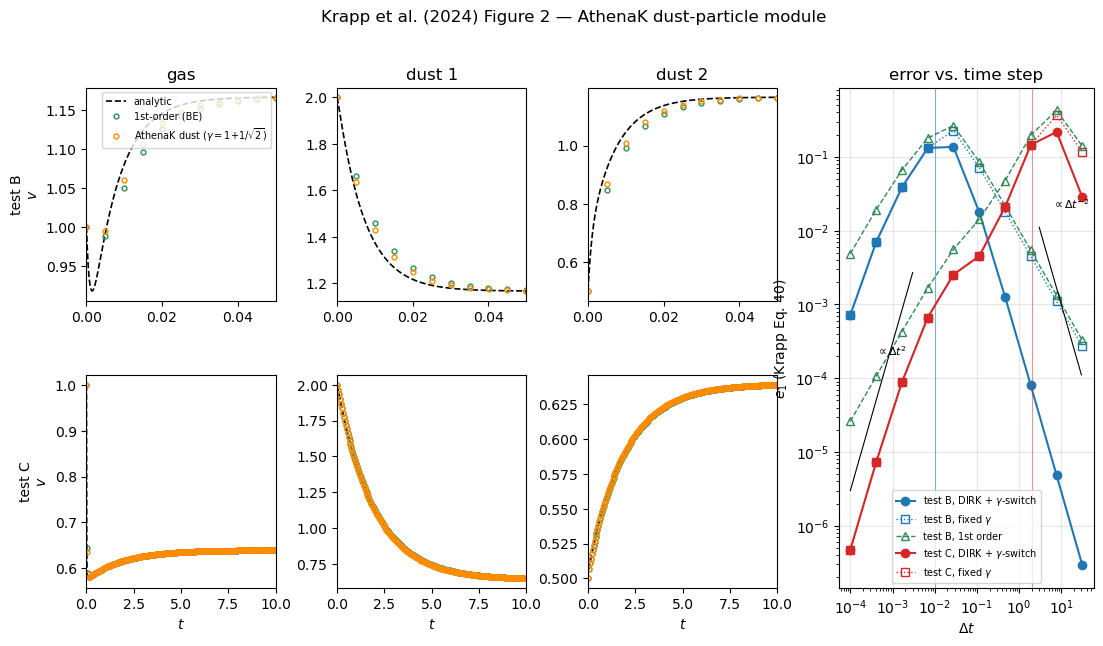

vertical lines: dt = max(t_s) where the gamma-switch (Krapp Eq. 18) activates


In [5]:
fig = plt.figure(figsize=(13,6.5))
gs = fig.add_gridspec(2, 4, width_ratios=[1,1,1,1.35], hspace=0.35, wspace=0.3)
labels = ['gas', 'dust 1', 'dust 2']
for row,k in enumerate(['B','C']):
    p = HB[k]
    t, vg, vd = panel[k]
    tfine = np.linspace(0, p['t_panel'], 2000)
    vga, vda = v_analytic(p, tfine)
    vbe = be_first_order(p, p['dt_panel'], int(p['t_panel']/p['dt_panel']))
    tbe = p['dt_panel']*np.arange(len(vbe))
    for col,(vnum,vana,vbe_c) in enumerate(zip([vg,*vd],[vga,*vda],[vbe[:,0],vbe[:,1],vbe[:,2]])):
        ax = fig.add_subplot(gs[row,col])
        ax.plot(tfine, vana, 'k--', lw=1.2, label='analytic')
        ax.plot(tbe, vbe_c, 'o', ms=3.5, mfc='none', color='seagreen', label='1st-order (BE)')
        ax.plot(t, vnum, 'o', ms=3.5, mfc='none', color='darkorange',
                label='AthenaK dust ($\\gamma=1{+}1/\\sqrt{2}$)')
        ax.set_xlim(0, p['t_panel'])
        if col==0: ax.set_ylabel(f'test {k}\n$v$')
        if row==1: ax.set_xlabel('$t$')
        if row==0: ax.set_title(labels[col])
        if row==0 and col==0: ax.legend(fontsize=7, loc='upper right')
axE = fig.add_subplot(gs[:,3])
for k,color in [('B','tab:blue'),('C','tab:red')]:
    e = scan[(k,'switch')]
    axE.loglog(e[:,0], e[:,1], 'o-', color=color, label=f'test {k}, DIRK + $\\gamma$-switch')
    e = scan[(k,'fixed')]
    axE.loglog(e[:,0], e[:,1], 's:', color=color, mfc='none', lw=1,
               label=f'test {k}, fixed $\\gamma$')
    e = scan[(k,'be1')]
    axE.loglog(e[:,0], e[:,1], '^--', color='seagreen', mfc='none', lw=1,
               label=(f'test {k}, 1st order' if k=='B' else None))
    axE.axvline(HB[k]['ts_max'], color=color, lw=0.8, alpha=0.5)
d = np.array([1e-4,3e-3]); axE.loglog(d, 3e2*d**2, 'k-', lw=0.8)
axE.text(4e-4, 2e-4, '$\\propto\\Delta t^{2}$', fontsize=8)
d = np.array([3e0,3e1]); axE.loglog(d, 1e-1*d**-2.0, 'k-', lw=0.8)
axE.text(6e0, 2e-2, '$\\propto\\Delta t^{-2}$', fontsize=8)
axE.set_xlabel('$\\Delta t$'); axE.set_ylabel('$e_1$ (Krapp Eq. 40)')
axE.set_title('error vs. time step')
axE.legend(fontsize=7); axE.grid(alpha=0.3)
fig.suptitle('Krapp et al. (2024) Figure 2 — AthenaK dust-particle module', y=1.00)
plt.savefig(WORK/'fig2_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
print('vertical lines: dt = max(t_s) where the gamma-switch (Krapp Eq. 18) activates')

**What to look for** (compare with the paper's Fig. 2):

- *Velocity panels*: at $\Delta t=0.005$ (test B) and $0.05$ (test C) both dust species are
  deep in the stiff regime. The second-order solution (orange) tracks the analytic dashed curve
  far better than the first-order one (green) and relaxes monotonically to $v_{\rm CM}$ —
  no oscillation, no instability, matching the fully-implicit rows of HB22's Fig. 2 and the
  DIRK curves of Krapp's Fig. 2.
- *Error panel*: in the resolved regime the error falls as $\Delta t^{2}$ (the first-order
  method is one to two orders worse and converges only linearly); past the vertical line
  ($\Delta t > \max t_s$, where Krapp Eq. 18 switches $\gamma\to1/2$) the error *decreases*
  again as $1/\Delta t^{2}$ — second-order asymptotic convergence to the equilibrium. The
  fixed-$\gamma$ curve (dotted) degrades to $\sim1/\Delta t$ there, which is exactly the
  motivation for the switch.

## 2. Figure 4 — five-fluid damped sound wave (BKP19 §3.2)

One gas + four dust species with dust-to-gas ratios $\epsilon = (0.1, 0.2\overline{3},
0.3\overline{6}, 0.5)$ and stopping times $t_s = 0.1\ldots1$ (log-spaced), $c_s=1$, $L=1$,
$k=2\pi$, amplitude $A=10^{-4}$ (BKP19 Table 2). The initial condition is the exact complex
eigenmode normalized so $\delta\hat\rho_g = A\rho_g$ (their convention); dust particles are
placed on a displaced lattice imprinting each species' density wave. BKP19 quote the eigenvalue
$\omega_{\rm BKP} = 0.912414 - 5.493800\,i$ (convention $e^{ikx-\omega t}$), which in our
convention $e^{i(kx-\omega t)}$ is $\omega = 5.493800 - 0.912414\,i$ — the code prints its
Newton-solved root in the error file and we assert the match.

The plotted quantity is the normalized density $\delta\rho_j/(\rho_j^0 A)$ of every fluid at
the first cell column ($x = \Delta x/2$), recorded every cycle by the user-history output: the
gas value is the column average of $\rho_g$, and each dust value is the TSC-deposited column
mass of that species (i.e. measured exactly the way the solver sees the dust density).

In [6]:
EPS5 = (0.1, 0.233333333, 0.366666667, 0.5)
TS5  = (0.1, 0.215443469, 0.464158883, 1.0)
AMP, CS, RHO0 = 1.0e-4, 1.0, 1.0

def wave_input(name, nx1, tlim=2.0, cfl=0.45, hist=False):
    ns = len(EPS5)
    taus_l = chr(10).join(f'taus_{s+1} = {TS5[s]!r}' for s in range(ns))
    eps_l  = chr(10).join(f'eps_{s+1} = {EPS5[s]!r}' for s in range(ns))
    mb1 = min(nx1, 64)
    hist_b = 'true' if hist else 'false'
    return f"""
<job>
basename = {name}
<mesh>
nghost = 2
nx1 = {nx1}\nx1min = 0.0\nx1max = 1.0\nix1_bc = periodic\nox1_bc = periodic
nx2 = 4\nx2min = 0.0\nx2max = {4.0/nx1!r}\nix2_bc = periodic\nox2_bc = periodic
nx3 = 1\nx3min = -0.5\nx3max = 0.5\nix3_bc = periodic\nox3_bc = periodic
<meshblock>
nx1 = {mb1}\nnx2 = 4\nnx3 = 1
<time>
evolution = dynamic\nintegrator = imex2+\ncfl_number = {cfl}\nnlim = -1\ntlim = {tlim!r}\nndiag = 100000
<hydro>
eos = isothermal\niso_sound_speed = {CS!r}\nreconstruct = plm\nrsolver = hlle
<particles>
particle_type = dust\npusher = imex_dust\nppc = {float(len(EPS5))!r}
<dust>
nspecies = {len(EPS5)}
{taus_l}
dust_to_gas = 1.2\nback_reaction = true\ndeposit = tsc\ngamma_switch = false\ndt_cfl = 0.5
<problem>
pgen_name = dusty_wave\nuser_hist = {hist_b}\nrho0 = {RHO0!r}\namp = {AMP!r}\nnormalization = density
{eps_l}
<output1>
file_type = hst\ndcycle = 1\ndata_format = %.14e
"""

def wave_omega(k, cs, eps, ts):
    eps, ts = np.asarray(eps), np.asarray(ts)
    w = k*cs/np.sqrt(1+eps.sum()) + 0j
    for _ in range(100):
        den = 1 - 1j*w*ts
        f  = w*w*(1 + np.sum(eps/den)) - (k*cs)**2
        fp = 2*w*(1 + np.sum(eps/den)) + w*w*np.sum(eps*1j*ts/den**2)
        dw = f/fp; w -= dw
        if abs(dw) < 1e-15*abs(w): break
    return w

kwv = 2*np.pi
omega = wave_omega(kwv, CS, EPS5, TS5)
print(f'dispersion root: {omega:.6f}   (BKP19 Table 2: 5.493800 - 0.912414i)')
assert abs(omega - (5.493800-0.912414j)) < 2e-6

# eigenmode amplitudes with the density normalization (gas density amplitude = A*rho0, real)
du = AMP*CS + 0j
drho = (kwv/omega)*RHO0*du
cfac = AMP*RHO0/drho
du *= cfac; drho = AMP*RHO0 + 0j
dv = [du/(1 - 1j*omega*t) for t in TS5]
drho_d = [e*RHO0*(kwv/omega)*v for e,v in zip(EPS5, dv)]   # dust continuity

dispersion root: 5.493800-0.912414j   (BKP19 Table 2: 5.493800 - 0.912414i)


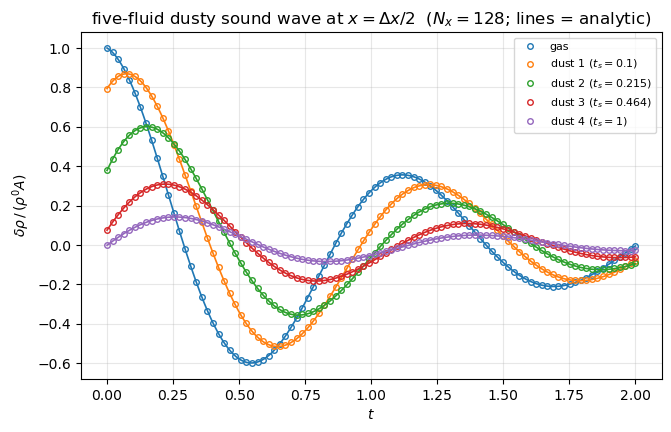

max |numerical - analytic| of normalized gas density: 1.496e-03


In [7]:
# time-evolution run and normalized-density comparison at the first cell column
NX = 128
run('wave5', wave_input('wave5', NX, hist=True))
u = np.atleast_2d(np.loadtxt(WORK/'wave5.user.hst'))
t = u[:,0]
dx = 1.0/NX; ncol = 4; vcell = dx*(4.0/NX)/4
xcol = 0.5*dx
rho_g_col = u[:,2]/ncol
norm_g = (rho_g_col - RHO0)/(RHO0*AMP)
norm_d = [(u[:,3+s]/(ncol*vcell) - EPS5[s]*RHO0)/(EPS5[s]*RHO0*AMP) for s in range(4)]

def analytic_norm(amp_c, bg, tt):
    ph = np.exp(1j*(kwv*xcol) - 1j*omega*tt)
    return (amp_c*ph).real/(bg*AMP)

fig, ax = plt.subplots(figsize=(7.5,4.5))
tf = np.linspace(0, 2, 1500)
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
ax.plot(tf, analytic_norm(drho, RHO0, tf), '-', color=colors[0], lw=1.2)
ax.plot(t[::6], norm_g[::6], 'o', ms=4, mfc='none', color=colors[0], label='gas')
for s in range(4):
    ax.plot(tf, analytic_norm(drho_d[s], EPS5[s]*RHO0, tf), '-', color=colors[s+1], lw=1.2)
    ax.plot(t[::6], norm_d[s][::6], 'o', ms=4, mfc='none', color=colors[s+1],
            label=f'dust {s+1} ($t_s={TS5[s]:.3g}$)')
ax.set_xlabel('$t$'); ax.set_ylabel('$\\delta\\rho\\,/\\,(\\rho^0 A)$')
ax.set_title(f'five-fluid dusty sound wave at $x=\\Delta x/2$  ($N_x={NX}$; lines = analytic)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.savefig(WORK/'fig4_top_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
resid = np.max(np.abs(norm_g - analytic_norm(drho, RHO0, t)))
print(f'max |numerical - analytic| of normalized gas density: {resid:.3e}')

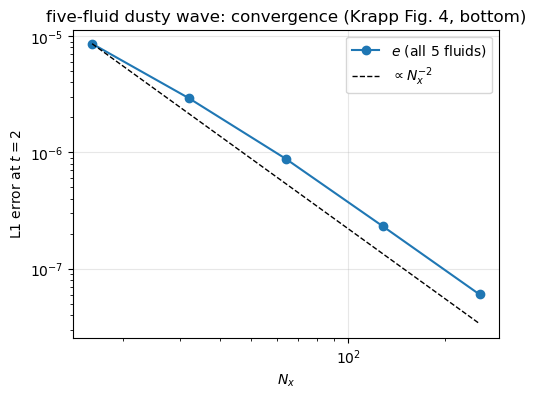

 Nx     e_tot
  16  8.6131e-06
  32  2.9253e-06
  64  8.8103e-07
 128  2.3204e-07
 256  6.0017e-08
overall convergence order: 1.79
note: the code-side error metric evaluates the gas fields on the grid and the dust
velocities at the particle positions (the Lagrangian analogue of Krapp Eq. 46).


In [8]:
# error convergence: e_tot = L1(drho_g) + L1(dv_g) + sum_s L1(dv_s at particles), at t=2
(WORK/'wave5c-errs.dat').unlink(missing_ok=True)
nxs = [16, 32, 64, 128, 256]
for nx in nxs:
    text = wave_input('wave5c', nx)
    inp = WORK/'wave5c.athinput'; inp.write_text(text)
    res = subprocess.run([str(ATHENA),'-i',str(inp)], cwd=WORK, capture_output=True, text=True)
    if res.returncode != 0: raise RuntimeError(res.stdout[-2000:])
E = np.atleast_2d(np.loadtxt(WORK/'wave5c-errs.dat'))
fig, ax = plt.subplots(figsize=(5.5,4))
ax.loglog(E[:,0], E[:,8], 'o-', label='$e$ (all 5 fluids)')
ax.loglog(E[:,0], E[0,8]*(E[0,0]/E[:,0])**2, 'k--', lw=1, label='$\\propto N_x^{-2}$')
ax.set_xlabel('$N_x$'); ax.set_ylabel('L1 error at $t=2$')
ax.set_title('five-fluid dusty wave: convergence (Krapp Fig. 4, bottom)')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(WORK/'fig4_bottom_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
order = np.log(E[0,8]/E[-1,8])/np.log(nxs[-1]/nxs[0])
print(' Nx     e_tot')
for r in E: print(f'{int(r[0]):4d}  {r[8]:.4e}')
print(f'overall convergence order: {order:.2f}')
assert order > 1.6, 'expected ~2nd order convergence'
print('note: the code-side error metric evaluates the gas fields on the grid and the dust')
print('velocities at the particle positions (the Lagrangian analogue of Krapp Eq. 46).')

## 3. Figure 5 — four-fluid steady shock: deferred to phase 3

Krapp's Figure 5 shows the steady multifluid shock of BKP19 §3.3.2 (their Table 3: gas + three
dust species, constant collision coefficients $K_i = (1,3,5)$, Mach number 2, $\epsilon_i = 1$,
isothermal $c_s = 1$), relaxed from a jump initial condition to $t=500$ and compared with the
exact steady solution.

This is fundamentally an *open-boundary Eulerian* test, and reproducing it with Lagrangian
particles requires machinery that is deliberately scheduled for phase 3 of the implementation
plan:

1. **Inflow/outflow boundaries for particles** — a steady shock in the shock frame needs a
   continuous stream of dust particles injected at the upstream boundary every stage (with
   correctly initialized IMEX registers mid-cycle) and removed at the downstream boundary. No
   particle creation/deletion machinery exists yet; the current module enforces strictly
   periodic domains.
2. **Non-periodic deposit and $u^*$ boundary handling** — ghost-zone deposits at open
   boundaries must be dropped consistently and the provisional gas velocity needs one-sided
   fills (phase-3 items in the plan).
3. **Constant-$K$ drag law** — the test defines $\rho_g\alpha_g = \rho_{d,i}\alpha_{d,i}
   \equiv K_i$ = const, so a particle's stopping time depends on the *local dust density*,
   $t_{s,i} = \rho_{d,i}/K_i$. The per-particle stopping time column supports this in
   principle, but it requires depositing the plain dust density and updating $t_s$ per stage —
   a new (small) kernel plus one more deposited field.

None of these affect the physics validated by Figures 2 and 4 (the drag solver, its coupling
to transport and pressure, stiffness, and momentum conservation). The shock test is the natural
first target once phase-3 boundary machinery lands; the parameters and the exact-solution ODEs
(BKP19 Eqs. 55–58) are recorded here for that purpose.

## 4. Summary

| Figure | Test | Status | Key check |
|---|---|---|---|
| 2 | HB22 collision tests B & C | reproduced | velocities track the tabulated analytic solution in the stiff regime; error $\propto\Delta t^2$ resolved, $\propto\Delta t^{-2}$ asymptotic with the $\gamma$-switch |
| 4 | BKP19 five-fluid dusty wave | reproduced | dispersion root matches Table 2 to 6 digits; all five normalized-density curves overlay the analytic eigenmode; $N_x^{-2}$ convergence |
| 5 | BKP19 four-fluid shock | deferred (phase 3) | needs particle inflow/outflow + constant-$K$ drag |

Reference values recorded during development (2026-07-14): Fig. 2 test B at $\Delta t=0.005$
final-state errors $\sim10^{-14}$; Fig. 4 dispersion root $5.493800 - 0.912414i$; five-fluid
$e(N_x)$: $N_x=16\to256$ decreasing by $\sim2$ orders of magnitude.